In [15]:
import shapefile
import geopandas as gpd
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from shapely.geometry import shape as shapely_shape

import torch
import networkx as nx
from torch_geometric.utils import to_networkx

import pickle
import tensorflow as tf
from sklearn.model_selection import train_test_split

## LOAD MODELS

In [6]:
# LSTM AE MODEL

lstm_autoencoder = tf.keras.models.load_model('../checkpoints/autoencoder/model/best_32_batches_100_epochs_huber_local_1411_1548.keras')

In [7]:
# LSTM AE MODEL
#loss = siamese_loss_wrapper(0.001)
#siamese_lstm_autoencoder = tf.keras.models.load_model('../checkpoints/siamese/model/16_batches_50_epochs_pretrained_local_1811_1801.keras', custom_objects={'siamese_loss': loss})

## LOAD INPUT DATA

In [ ]:
# SIAMESE & AE 
PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_local_original.npy'
PATH_TRAINING_B =  '../data/preprocessing/normalized/normalized_local_close.npy'

PATH_TRAINING_A_CLEAN = '../data/preprocessing/normalized/normalized_local_original.npy'
PATH_TRAINING_B_CLEAN = '../data/preprocessing/normalized/normalized_local_far.npy'

In [31]:
# LSTM AE 
lstm_ae_noisy = np.load(PATH_TRAINING_A)

lstm_ae_train, temp = train_test_split(lstm_ae_noisy, test_size=0.2, random_state=42)  
lstm_ae_val, lstm_ae_test = train_test_split(temp, test_size=0.5, random_state=42) 

print(f'Train Shape {lstm_ae_train.shape}, Val Shape {lstm_ae_val.shape}, Test Shape {lstm_ae_test.shape}')

Train Shape (54822, 64, 2), Val Shape (6853, 64, 2), Test Shape (6853, 64, 2)


In [ ]:
#SIAMESE

# Load full arrays
lines_a_noisy = np.load(PATH_TRAINING_A)[:20000]
lines_b_noisy = np.load(PATH_TRAINING_B)[:20000]
lines_a_clean = np.load(PATH_TRAINING_A_CLEAN)[:20000]
lines_b_clean = np.load(PATH_TRAINING_B_CLEAN)[:20000]

# Total number of samples
n_total = lines_a_noisy.shape[0]

# Compute split indices
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

# --- TRAIN ---
train_slice = slice(0, n_train)
lines_a_noisy_train = lines_a_noisy[train_slice]
lines_b_noisy_train = lines_b_noisy[train_slice]
lines_a_clean_train = lines_a_clean[train_slice]
lines_b_clean_train = lines_b_clean[train_slice]

# --- VALIDATION ---
val_slice = slice(n_train, n_train + n_val)
lines_a_noisy_val = lines_a_noisy[val_slice]
lines_b_noisy_val = lines_b_noisy[val_slice]
lines_a_clean_val = lines_a_clean[val_slice]
lines_b_clean_val = lines_b_clean[val_slice]

# --- TEST ---
test_slice = slice(n_train + n_val, n_total)
lines_a_noisy_test = lines_a_noisy[test_slice]
lines_b_noisy_test = lines_b_noisy[test_slice]
lines_a_clean_test = lines_a_clean[test_slice]
lines_b_clean_test = lines_b_clean[test_slice]


print(f'Train: {lines_a_noisy_train.shape}, Val: {lines_a_noisy_val.shape}, Test: {lines_a_noisy_test.shape}')

Train: (14000, 64, 2), Val: (3000, 64, 2), Test: (3000, 64, 2)


## LOAD PREDICTED DATA

In [17]:
# GRAPH PREDICTIONS
 
with open('../data/results/graph/1_batches_50_epochs_0112_1158_delaunay_graph.pkl', 'rb') as f:
    all_predictions = pickle.load(f)


In [28]:
# LSTM AE 

with open('../data/results/lstm_autoencoder/32_batches_100_epochs_huber_local_1411_1548_lstm_autoencoder_predictions.pkl', 'rb') as f:
    lstm_pred = pickle.load(f)

In [29]:
# SIAMESE LSTM AE PREDICTIONS
 
with open('../data/results/siamese_lstm_autoencoder/16_batches_50_epochs_pretrained_local_1811_1801_siamese_lstm_autoencoder_predictions.pkl', 'rb') as f:
    data = pickle.load(f)

siamese_pred_a = data["pred_siamese_a"]
siamese_pred_b = data["pred_siamese_b"]

## PLOTTING RESULTS

### TRAINING LOSSES

In [40]:
# LSTM AE 
#history = np.load(''../checkpoints/autoencoder/history/ae_history.npy')
#epochs = 50
#batch_size = 16

def plot_history(history, epochs, batch_size, train_data_noisy):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='#143642')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#EC9A29')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training Loss LSTM AE {epochs} Epochs {batch_size} Batches and Training Data Shape: {train_data_noisy.shape}')
    plt.show()


#plot_history(history, epochs, batch_size, lines_a_noisy)

In [41]:
# SIAMESE LSTM AE 
#history = np.load(''../checkpoints/siamese/history/siamese_history.npy')
#epochs = 50
#batch_size = 16

#plot_history(history, epochs, batch_size, lines_a_noisy)

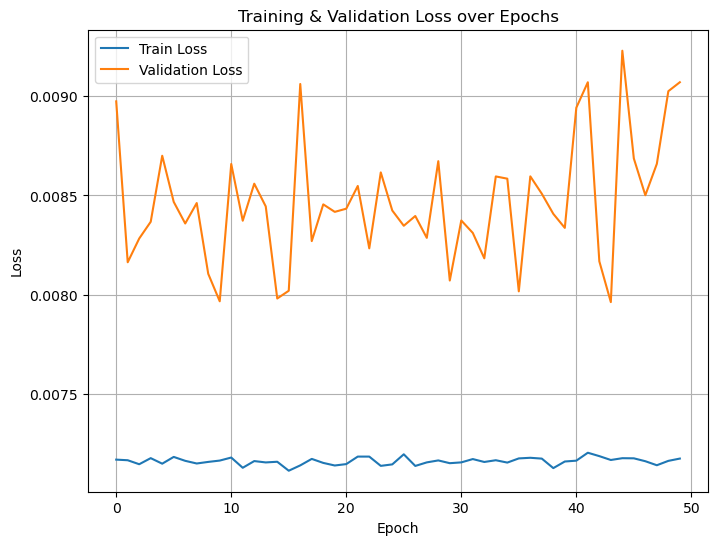

In [39]:
# GAT 
train_losses = np.load('../checkpoints/graph/history/1_batches_50_epochs_0112_1158_delaunay_train_loss.np.npy')
val_losses = np.load('../checkpoints/graph/history/1_batches_50_epochs_0112_1158_delaunay_val_loss.np.npy')
epochs = 50

plt.figure(figsize=(8,6))
plt.plot(range(0, epochs + 0), train_losses, label='Train Loss') #range(1, epochs+1)
plt.plot(range(0, epochs + 0), val_losses, label='Validation Loss') #range(1, epochs+1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### ERRORS (MSE & Euclidian Error)

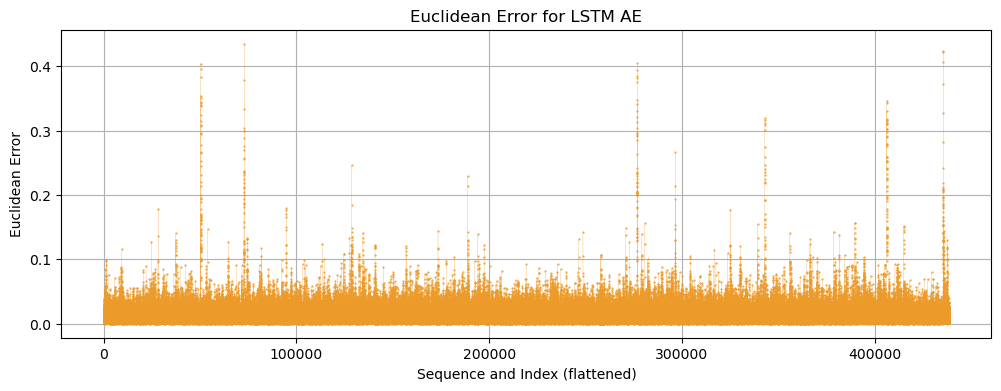

In [32]:
# LSTM AE  
# Compute Euclidean error for all sequences and timesteps
lstm_ae_all_errors = np.linalg.norm(lstm_ae_test[:] - lstm_pred[:], axis=-1)

# Flatten all errors into one 1D array
lstm_ae_all_errors_flat = lstm_ae_all_errors.flatten()  

# Plot all errors as one continuous line
plt.figure(figsize=(12, 4))
plt.plot(lstm_ae_all_errors_flat, color='#EC9A29', linewidth=0.1, marker='o', linestyle='-', markersize=0.5, label='Errors')
plt.title('Euclidean Error for LSTM AE')
plt.xlabel('Sequence and Index (flattened)')
plt.ylabel('Euclidean Error')
plt.grid(True)
plt.show()

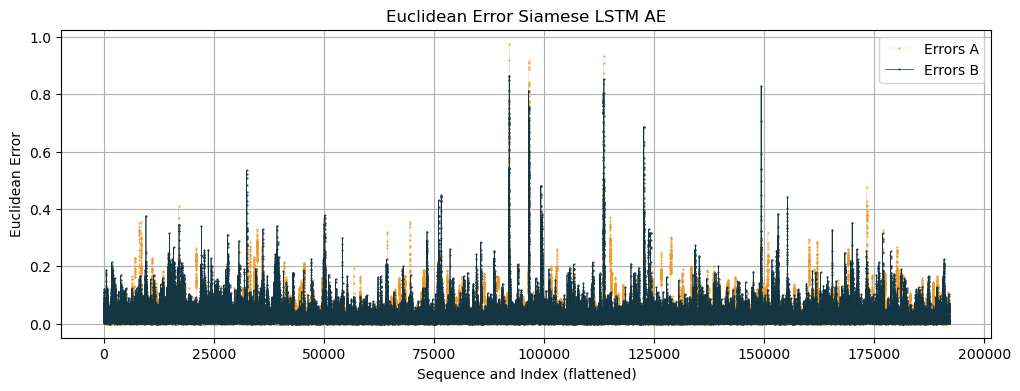

In [36]:
# SIAMESE 
# Compute Euclidean error for all sequences and timesteps
siamese_all_errors_a = np.linalg.norm(lines_a_clean_test[:] - siamese_pred_a[:], axis=-1)
siamese_all_errors_b = np.linalg.norm(lines_b_clean_test[:] - siamese_pred_b[:], axis=-1)

# Flatten all errors into one 1D array
all_errors_flat_a = siamese_all_errors_a.flatten()  
all_errors_flat_b = siamese_all_errors_b.flatten()

# Plot all errors as one continuous line
plt.figure(figsize=(12, 4))
plt.plot(all_errors_flat_a, color='#EC9A29', linewidth=0.1, marker='o', linestyle='-', markersize=0.5, label='Errors A')
plt.plot(all_errors_flat_b, color='#143642', linewidth=0.5, marker='o', linestyle='-', markersize=0.5, label='Errors B')
plt.title('Euclidean Error Siamese LSTM AE')
plt.xlabel('Sequence and Index (flattened)')
plt.ylabel('Euclidean Error')
plt.legend()
plt.grid(True)
plt.show()

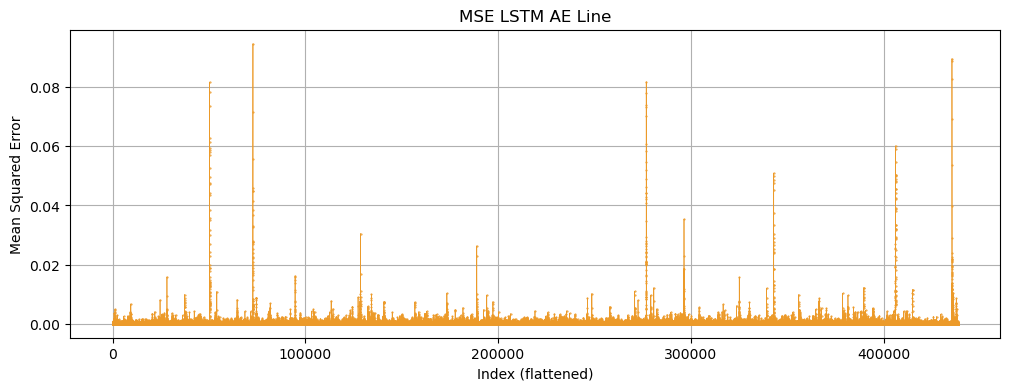

In [37]:
# LSTM AE 
# Compute MSE per point (squared error averaged over features)
mse_all = np.mean((lstm_ae_test[:] - lstm_pred[:]) ** 2, axis=-1)  # shape: [num_sequences, sequence_length]

# Flatten for one continuous plot
mse_all_flat = mse_all.flatten()

plt.figure(figsize=(12, 4))
plt.plot(mse_all_flat, color='#EC9A29', linewidth=0.5, marker='o', markersize=0.5,linestyle='-')
plt.title('MSE LSTM AE Line')
plt.xlabel('Index (flattened)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

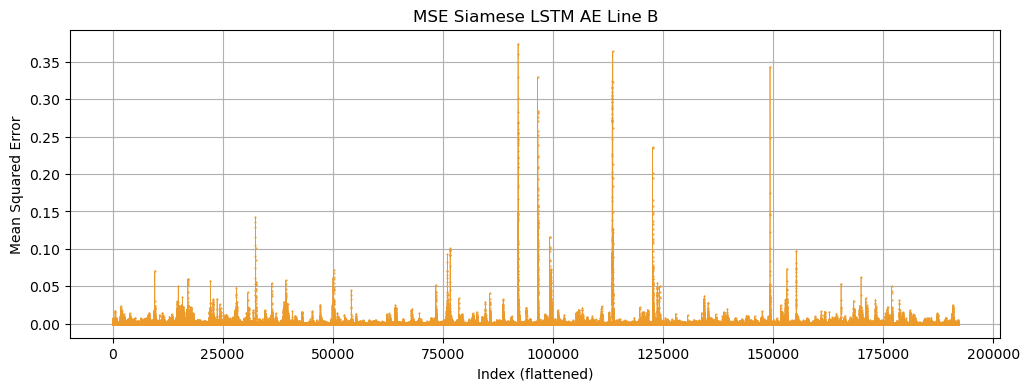

In [35]:
# SIAMESE 
# Compute MSE per point (squared error averaged over features)
mse_all = np.mean((lines_b_clean_test[:] - siamese_pred_b[:]) ** 2, axis=-1)  # shape: [num_sequences, sequence_length]

# Flatten for one continuous plot
mse_all_flat = mse_all.flatten()

plt.figure(figsize=(12, 4))
plt.plot(mse_all_flat, color='#EC9A29', linewidth=0.5, marker='o', markersize=0.5,linestyle='-')
plt.title('MSE Siamese LSTM AE Line B')
plt.xlabel('Index (flattened)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

### GRAPHICAL VISUALIZATION

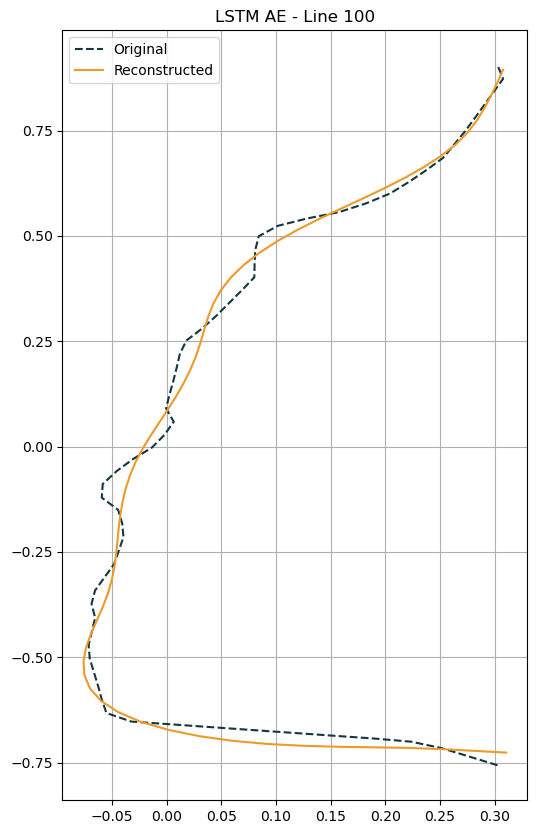

In [60]:
for i in range(100,101):
    plt.figure(figsize=(6, 10))
    plt.plot(lstm_ae_test[i,:,0], lstm_ae_test[i,:,1], color='#143642', linestyle='--',label='Original')
    plt.plot(lstm_pred[i,:,0], lstm_pred[i,:,1], color='#EC9A29',label='Reconstructed')
    plt.legend()
    #plt.axis('equal')
    plt.grid(True)
    plt.title(f'LSTM AE - Line {i}')
    plt.show()


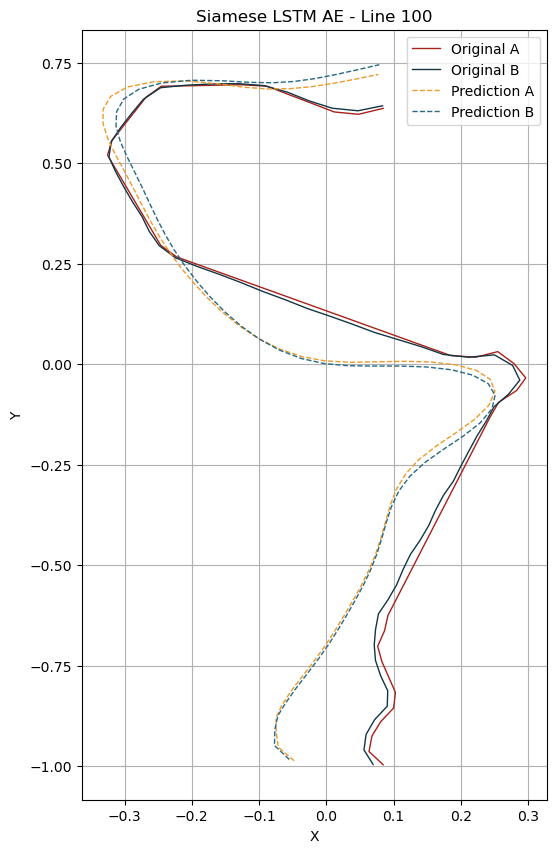

In [61]:
# SIAMESE 
# PLOTTING RESULTS
plt.figure(figsize=(6, 10))
start_plot = 100
end_plot = start_plot + 1

# Plot training segments A
for i, segment in enumerate(lines_a_noisy_test[start_plot:end_plot,:,:]):
    plt.plot(segment[:, 0], segment[:, 1],
             color='#A8201A', linewidth=1,
             label='Original A' if i == 0 else '')

# Plot training segments B
for i, segment in enumerate(lines_b_noisy_test[start_plot:end_plot,:,:]):
    plt.plot(segment[:, 0], segment[:, 1],
             color='#143642', linewidth=1,
             label='Original B' if i == 0 else '')
    
# Plot training segments B
# for i, segment in enumerate(lines_b_clean_test[start_plot:end_plot,:,:]):
#     plt.plot(segment[:, 0], segment[:, 1],
#              color='#1D431F', linewidth=0.75,
#              label='Groundtruth B' if i == 0 else '')

# Plot predicted segments A
for i, segment in enumerate(siamese_pred_a[start_plot:end_plot,:,:]):
     plt.plot(segment[:, 0], segment[:, 1],
            color='#EC9A29', linestyle='--', linewidth=1,
            label='Prediction A' if i == 0 else '')

# Plot predicted segments B
for i, segment in enumerate(siamese_pred_b[start_plot:end_plot,:,:]):
     plt.plot(segment[:, 0], segment[:, 1],
            color='#286981', linestyle='--', linewidth=1,
            label='Prediction B' if i == 0 else '')

plt.title(f'Siamese LSTM AE - Line {start_plot}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()